In [14]:
import numpy as np
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [15]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [17]:
df.rename(columns={'Annual Income (k$)':'Annual Income','Spending Score (1-100)':'Spending Score'},inplace=True)
df.head()

,CustomerID,Gender,Age,Annual Income,Spending Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

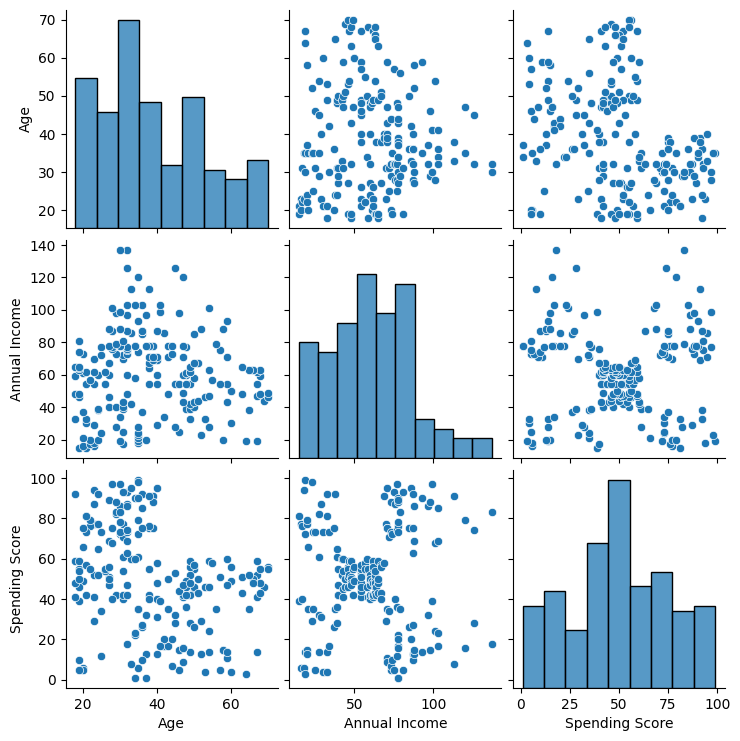

In [19]:
sns.pairplot(df[['Age','Annual Income','Spending Score']])
plt.show()

Text(0.5, 1.0, 'Annual Income vs Spending Score')

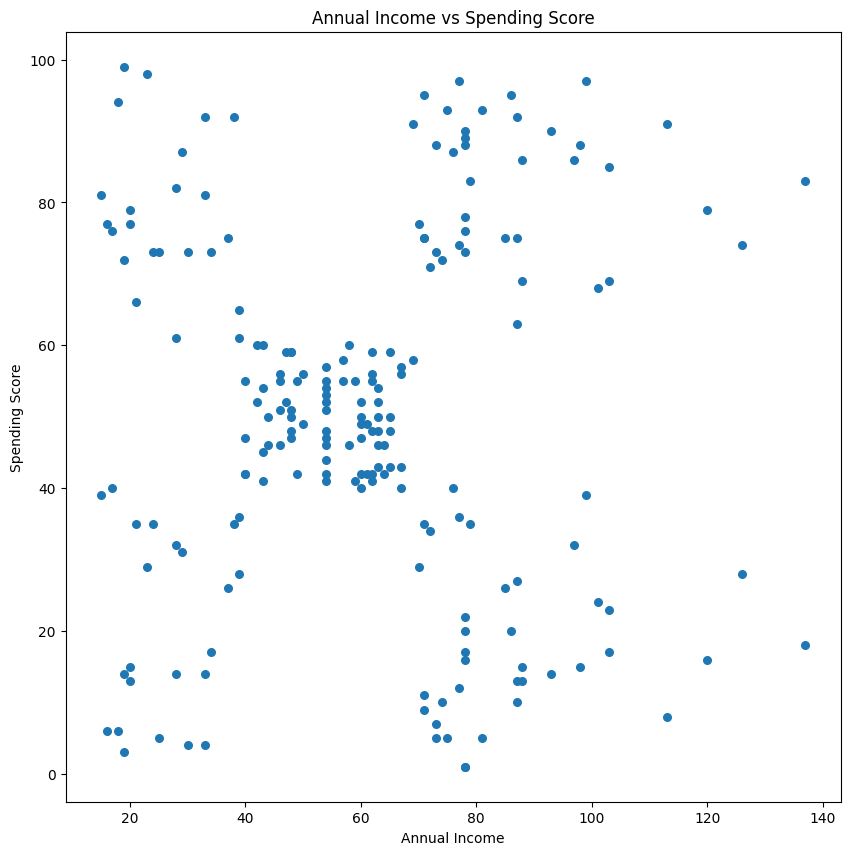

In [62]:
x = df[['Annual Income', 'Spending Score']]

plt.figure(figsize=(10,10))
plt.scatter(x.iloc[:,0], x.iloc[:,1], s=30)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Annual Income vs Spending Score')

In [63]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++',max_iter=300,n_init=10,random_state=0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
    

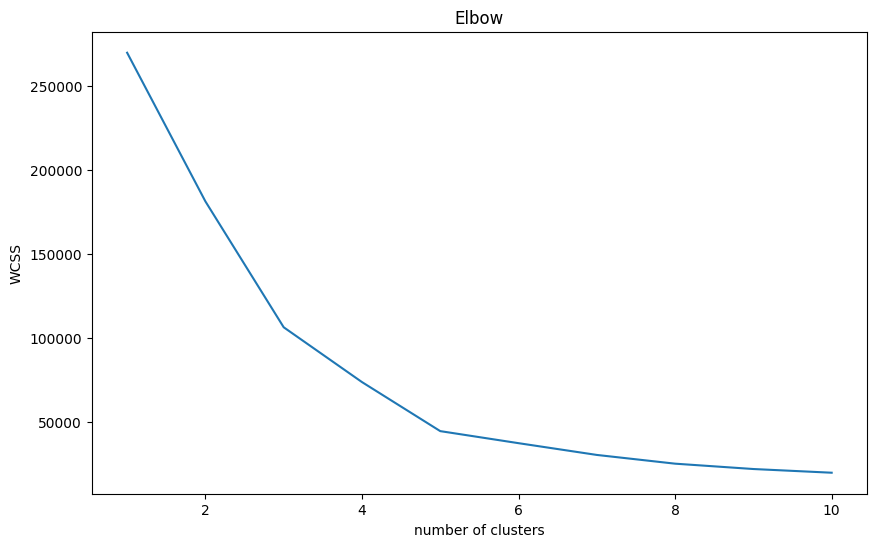

In [64]:
plt.figure(figsize=(10,6))
plt.plot(range(1,11),wcss)
plt.xlabel('number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow')
plt.show()

In [65]:
kmeans = KMeans(n_clusters=5, init='k-means++',max_iter=300,n_init=10,random_state=0)
kmeans.fit(x_scaled)
y_kmeans = kmeans.fit_predict(x_scaled)

In [66]:
df['clusters'] = y_kmeans

In [67]:
df.head()

,CustomerID,Gender,Age,Annual Income,Spending Score,clusters
0,1,Male,19,15,39,3
1,2,Male,21,15,81,4
2,3,Female,20,16,6,3
3,4,Female,23,16,77,4
4,5,Female,31,17,40,3


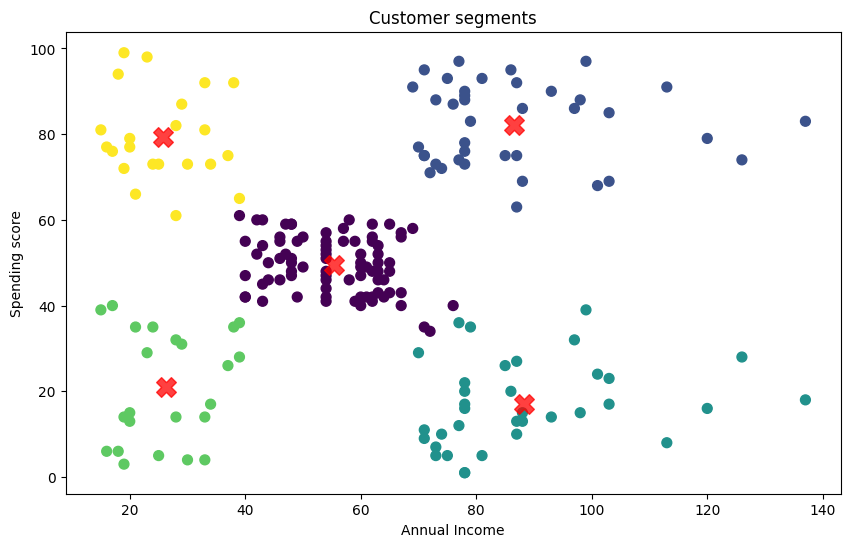

In [68]:
plt.figure(figsize=(10,6))
plt.scatter(x.iloc[:,0], x.iloc[:,1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], c='red', s=200, alpha=0.75, marker='X')
plt.xlabel('Annual Income')
plt.ylabel('Spending score')
plt.title('Customer segments')
plt.show()

<Axes: xlabel='Annual Income', ylabel='Spending Score'>

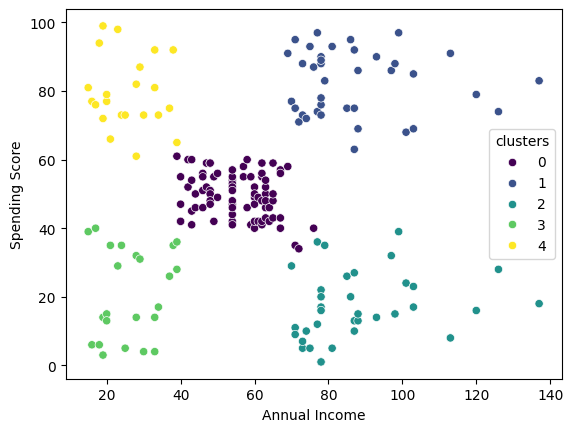

In [69]:
import seaborn as sns
sns.scatterplot(
    data=df,
    x='Annual Income',
    y='Spending Score',
    hue='clusters',
    palette='viridis'
)

Text(0.5, 1.0, 'Age vs Spending Score')

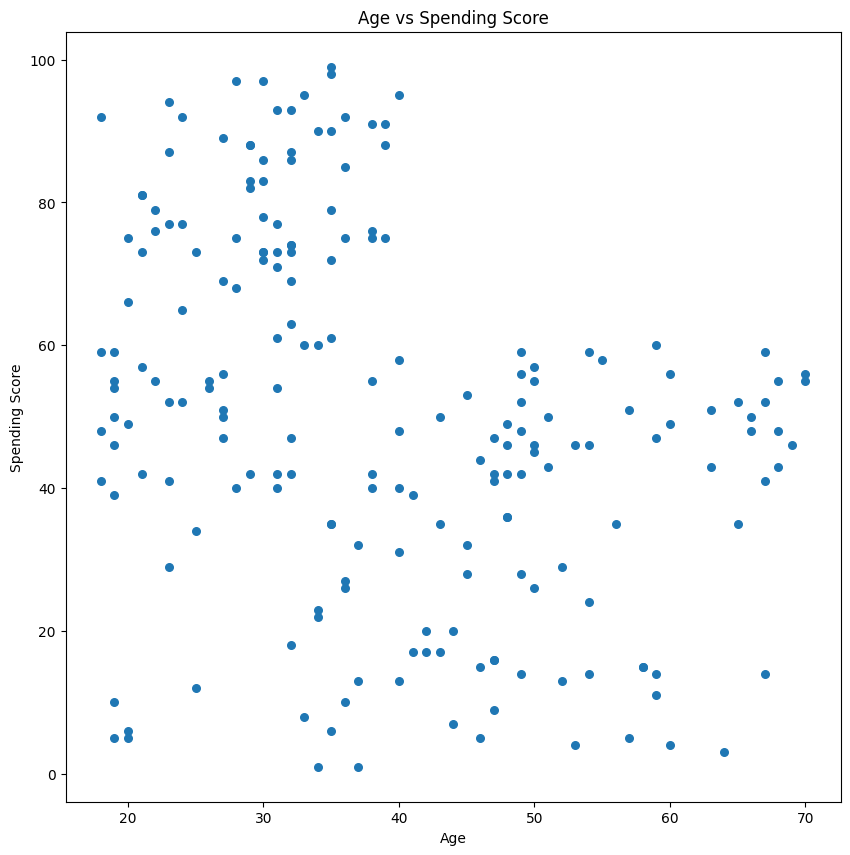

In [70]:

x = df[['Age', 'Spending Score']]

plt.figure(figsize=(10,10))
plt.scatter(x.iloc[:,0], x.iloc[:,1], s=30)
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.title('Age vs Spending Score')

In [71]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++',max_iter=300,n_init=10,random_state=0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
    

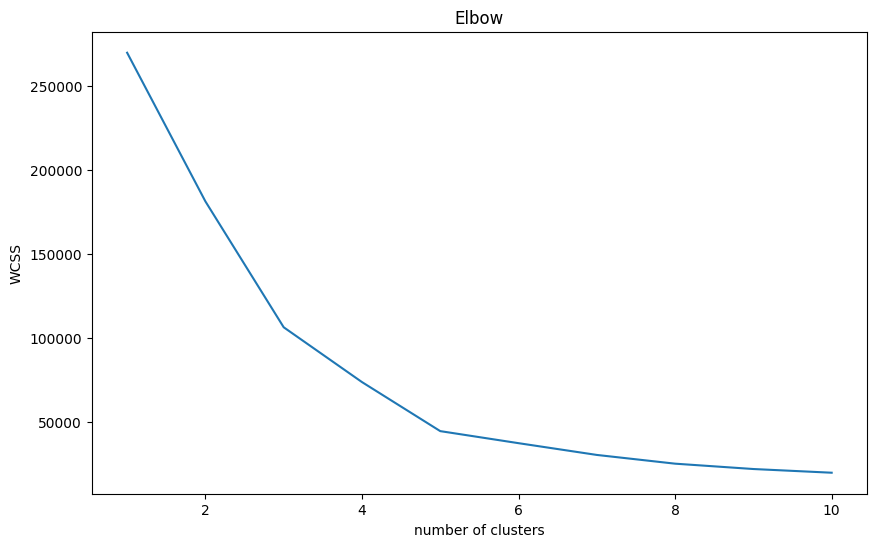

In [72]:
plt.figure(figsize=(10,6))
plt.plot(range(1,11),wcss)
plt.xlabel('number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow')
plt.show()

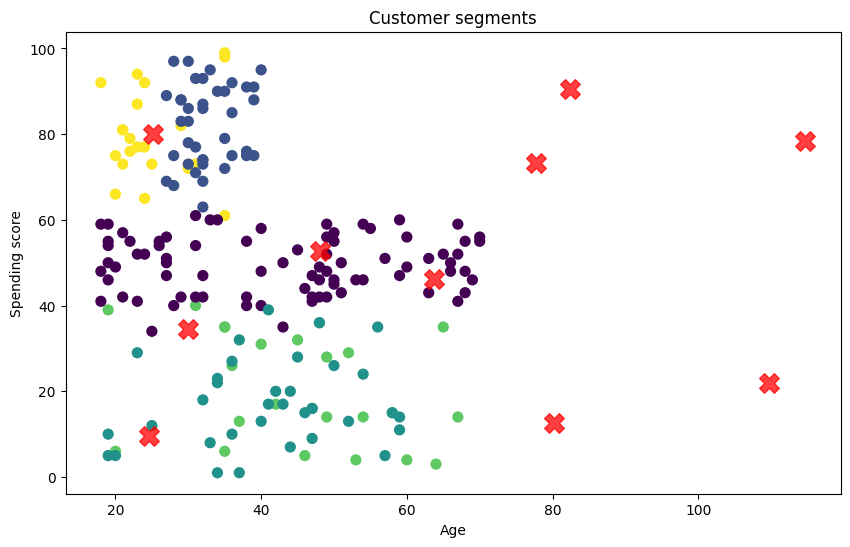

In [74]:
plt.figure(figsize=(10,6))
plt.scatter(x.iloc[:,0], x.iloc[:,1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], c='red', s=200, alpha=0.75, marker='X')
plt.xlabel('Age')
plt.ylabel('Spending score')
plt.title('Customer segments')
plt.show()

<Axes: xlabel='Age', ylabel='Spending Score'>

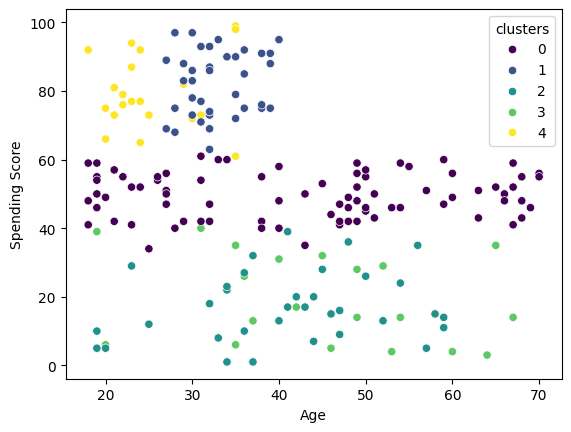

In [75]:
import seaborn as sns
sns.scatterplot(
    data=df,
    x='Age',
    y='Spending Score',
    hue='clusters',
    palette='viridis'
)

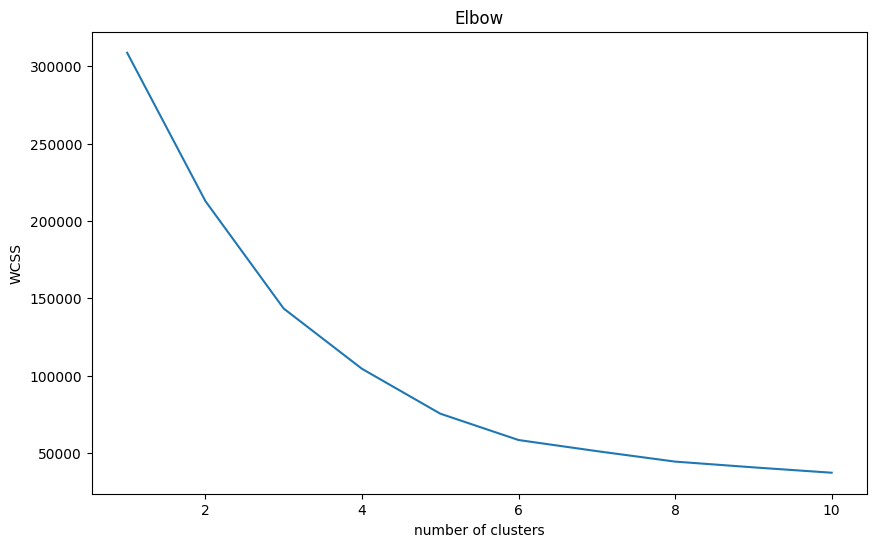

In [77]:

x = df[['Age','Annual Income', 'Spending Score']]
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++',max_iter=300,n_init=10,random_state=0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
    
plt.figure(figsize=(10,6))
plt.plot(range(1,11),wcss)
plt.xlabel('number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow')
plt.show()    

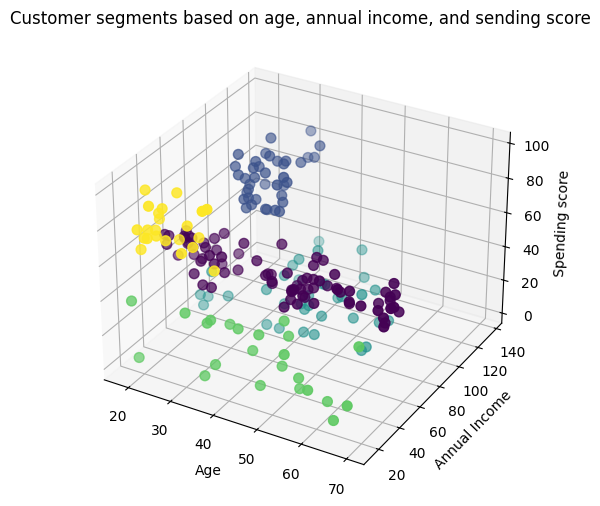

In [78]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111,projection='3d')
ax.scatter(df['Age'],df['Annual Income'],df['Spending Score'], c=y_kmeans, s=50, cmap='viridis')
ax.set_xlabel('Age')
ax.set_ylabel('Annual Income')
ax.set_zlabel('Spending score')
plt.title('Customer segments based on age, annual income, and sending score')
plt.show()